<a href="https://colab.research.google.com/github/emerson-marreiros/fronteira_voronoi/blob/main/Fronteira_Voronoi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

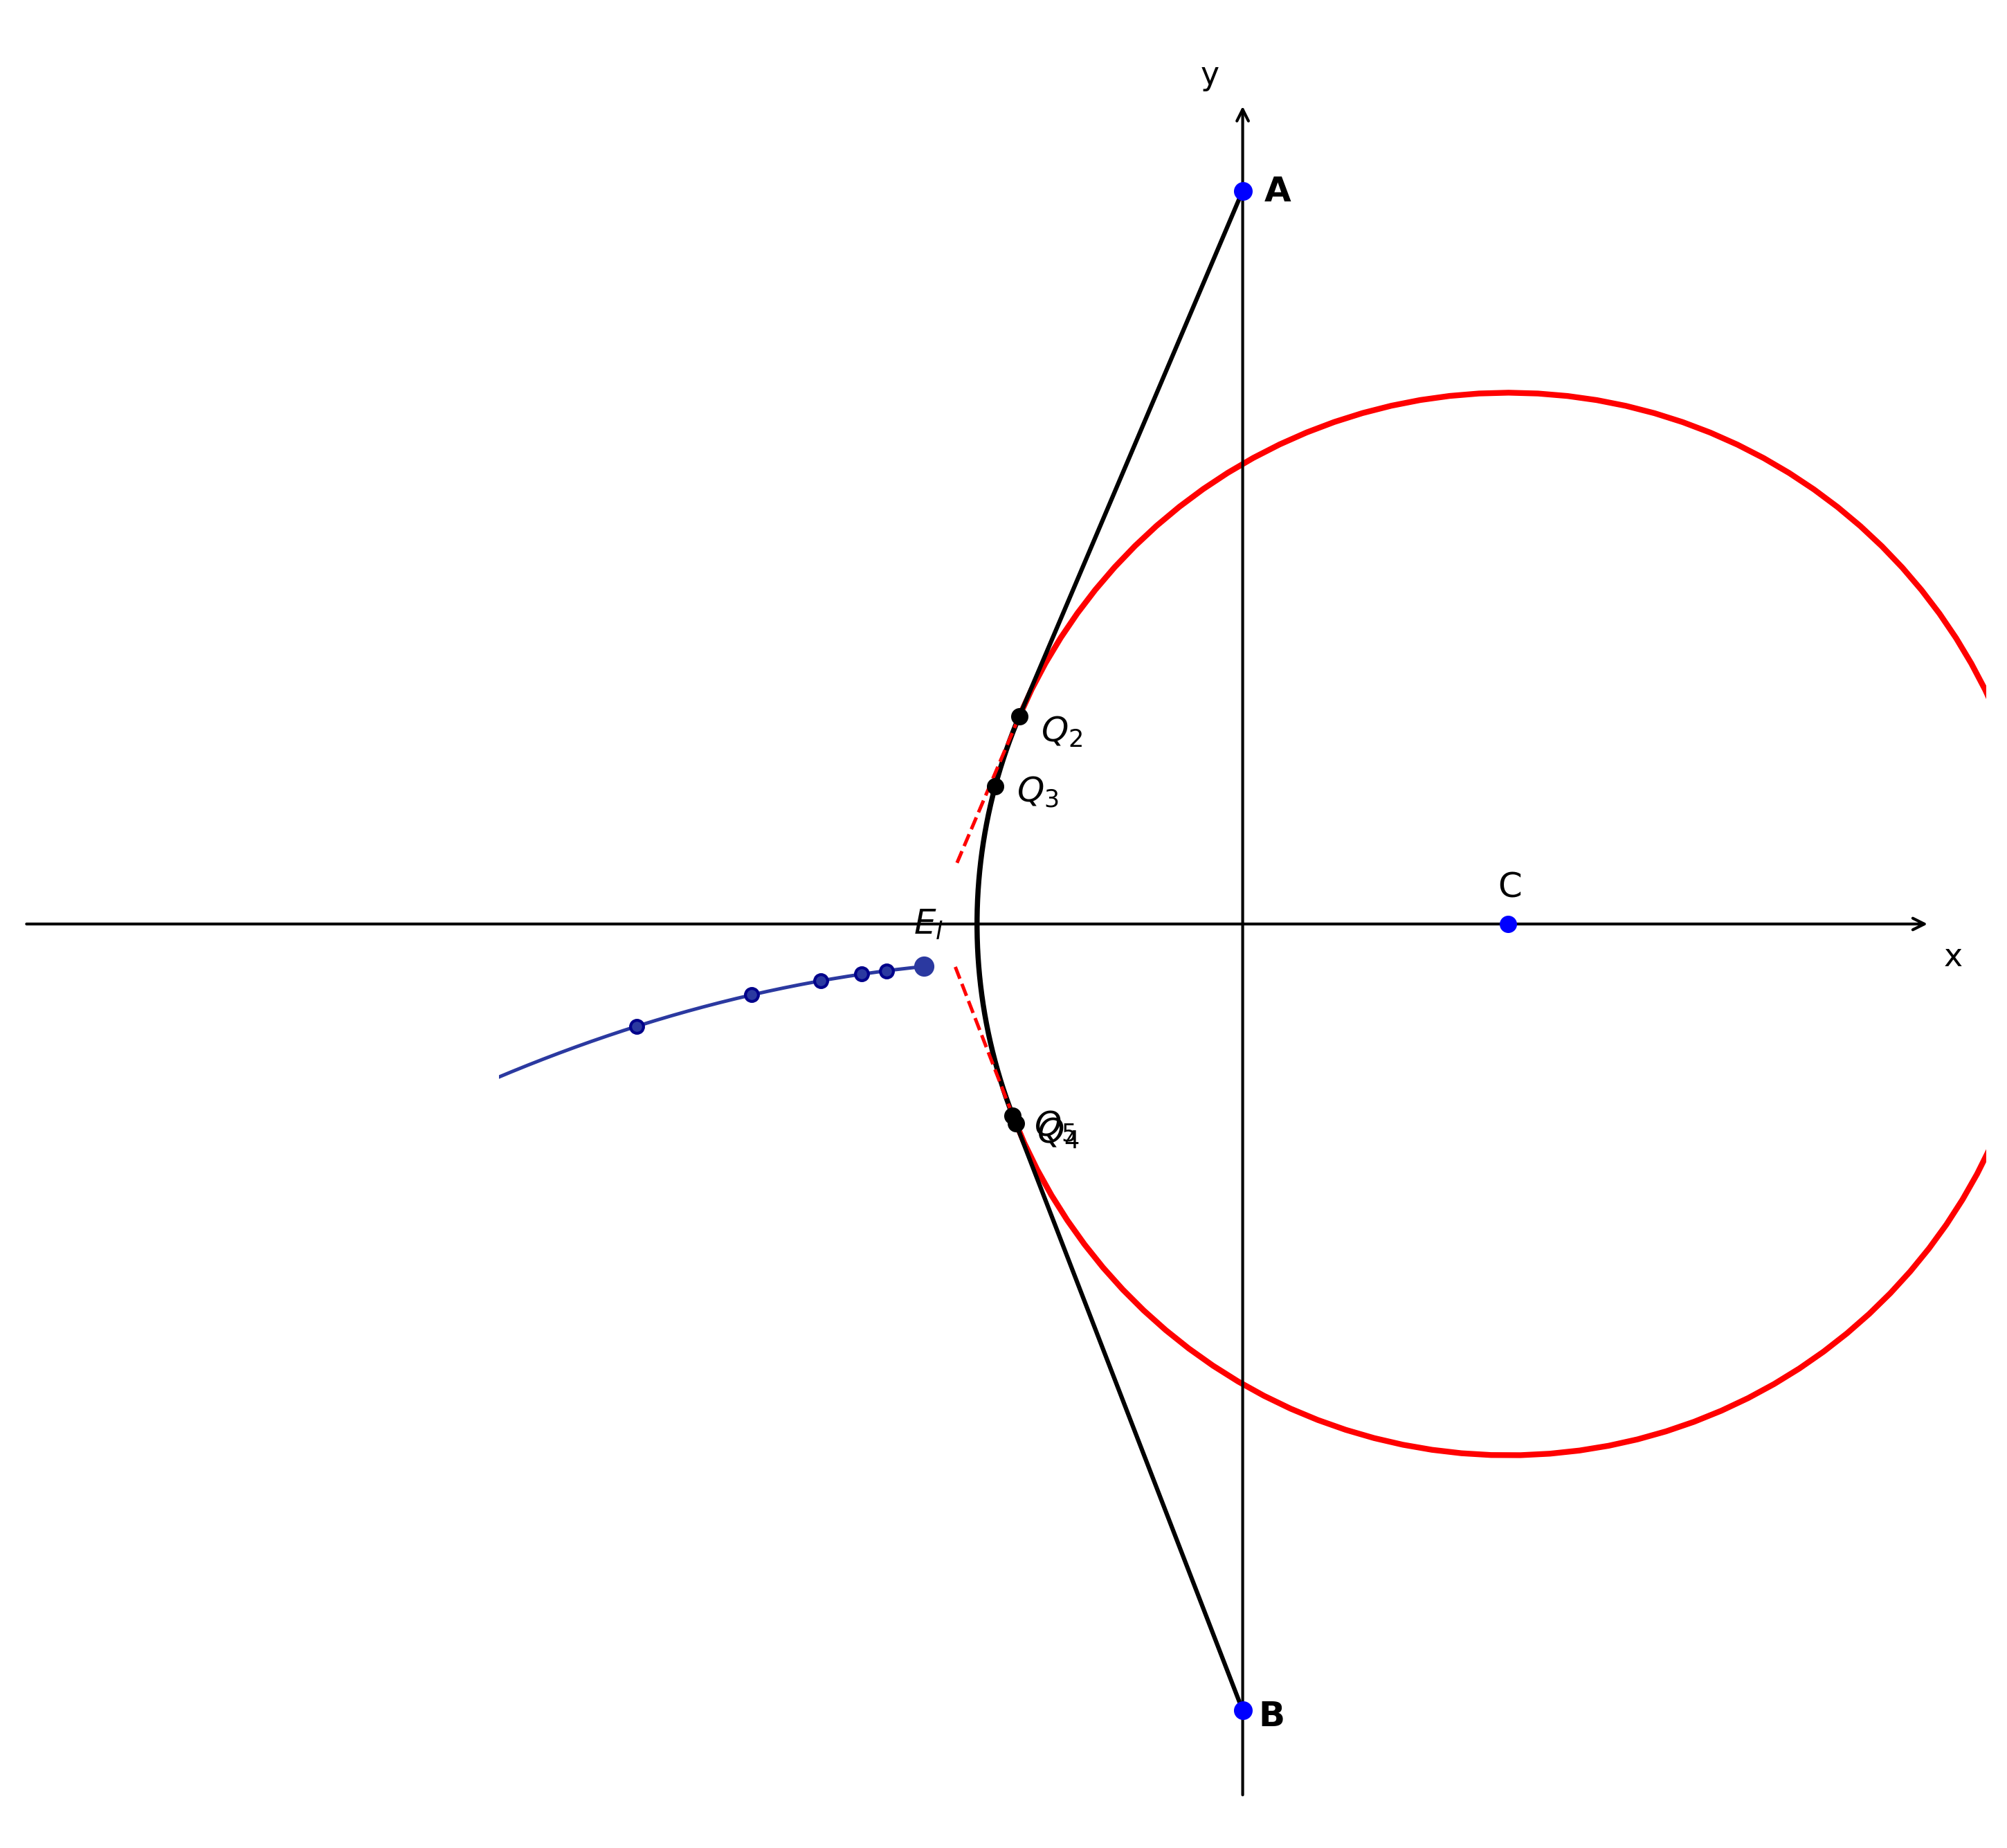

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Configuração da figura e resolução
fig, ax = plt.subplots(figsize=(9, 9), dpi=300)

# 1. Parâmetros da Circunferência e Pontos Notáveis
xc, yc = 0.5, 0.0  # Centro C
R = 1.0  # Raio da circunferência

y_A = 1.38  # Ponto A no eixo y positivo
y_B = -1.48  # Ponto B no eixo y negativo

A = np.array([0.0, y_A])
B = np.array([0.0, y_B])
C = np.array([xc, yc])

# 2. Cálculo geométrico dos pontos de tangência Q2 e Q5
vA = A - C
dA = np.linalg.norm(vA)
theta_A = np.arctan2(vA[1], vA[0])
alpha_A = np.arccos(R / dA)
angle_Q2 = theta_A + alpha_A
Q2 = C + R * np.array([np.cos(angle_Q2), np.sin(angle_Q2)])

vB = B - C
dB = np.linalg.norm(vB)
theta_B = np.arctan2(vB[1], vB[0])
alpha_B = np.arccos(R / dB)
angle_Q5 = theta_B - alpha_B
Q5 = C + R * np.array([np.cos(angle_Q5), np.sin(angle_Q5)])

# Pontos intermediários na fronteira
angle_Q3 = np.radians(165)  # 2º Quadrante
angle_Q4 = np.radians(202)  # 3º Quadrante
Q3 = C + R * np.array([np.cos(angle_Q3), np.sin(angle_Q3)])
Q4 = C + R * np.array([np.cos(angle_Q4), np.sin(angle_Q4)])

# 3. Traço da Circunferência e Fronteira
# Arco Preto Principal
theta_black = np.linspace(angle_Q5, angle_Q2 - 2 * np.pi, 300)
ax.plot(
    xc + R * np.cos(theta_black),
    yc + R * np.sin(theta_black),
    "k-",
    linewidth=1.8,
)

# Fronteira Vermelha (Arco de Q2 a Q5)
theta_red = np.linspace(angle_Q2, angle_Q5, 100)
ax.plot(
    xc + R * np.cos(theta_red),
    yc + R * np.sin(theta_red),
    color="red",
    linewidth=2.0,
)

# Segmentos Tangentes e Extensões Tracejadas
ax.plot([A[0], Q2[0]], [A[1], Q2[1]], "k-", linewidth=1.5)
ax.plot([B[0], Q5[0]], [B[1], Q5[1]], "k-", linewidth=1.5)

ext_Q2 = Q2 + 0.30 * (Q2 - A) / np.linalg.norm(Q2 - A)
ext_Q5 = Q5 + 0.30 * (Q5 - B) / np.linalg.norm(Q5 - B)
ax.plot([Q2[0], ext_Q2[0]], [Q2[1], ext_Q2[1]], "r--", linewidth=1.2)
ax.plot([Q5[0], ext_Q5[0]], [Q5[1], ext_Q5[1]], "r--", linewidth=1.2)

# 4. PONTO E_i EM (valores para x, valores para y) E CONVERGÊNCIA DOS PONTOS AZUIS

Ei = np.array([-0.6, -0.08])  # Coordenadas fixadas

n_dots = 8  # Número de pontos na sequência
d0 = 1.50  # Distância do ponto inicial (mais distante à esquerda)
r = 0.60  # Razão de convergência geométrica

# Distâncias decrescentes terminando exatamente em 0 (ponto Ei)
k_vals = np.arange(n_dots - 1)
distances = np.append(d0 * (r**k_vals), 0.0)

# Posições dos pontos azuis convergindo para Ei
x_dots = Ei[0] - distances
y_dots = Ei[1] - 0.10 * distances - 0.20 * (distances**2)

# Linha contínua suave ligando a sequência
x_fine = np.linspace(x_dots[0], Ei[0], 200)
d_fine = Ei[0] - x_fine
y_fine = Ei[1] - 0.10 * d_fine - 0.20 * (d_fine**2)

ax.plot(x_fine, y_fine, color="#2b39a0", linewidth=1.2, zorder=3)

# Plota os pontos azuis da sequência
ax.plot(
    x_dots,
    y_dots,
    "o",
    color="#2b39a0",
    markeredgecolor="darkblue",
    markersize=4.5,
    zorder=4,
)

# Destaque do ponto Ei no final da trajetória
ax.plot(Ei[0], Ei[1], "o", color="#2b39a0", markersize=6, zorder=5)

# 5. Eixos Cartesianos (Adaptados para o novo limite à esquerda)
ax.annotate(
    "",
    xy=(1.3, 0),
    xytext=(-2.3, 0),
    arrowprops=dict(arrowstyle="->", lw=1, color="black"),
)
ax.annotate(
    "",
    xy=(0, 1.55),
    xytext=(0, -1.65),
    arrowprops=dict(arrowstyle="->", lw=1, color="black"),
)
ax.text(1.32, -0.08, "x", fontsize=11)
ax.text(-0.08, 1.58, "y", fontsize=11)

# 6. Rótulos dos Pontos
ax.scatter([C[0]], [C[1]], color="blue", s=25, zorder=5)
ax.text(C[0] - 0.02, C[1] + 0.05, "C", fontsize=12)

ax.scatter([A[0]], [A[1]], color="blue", s=30, zorder=5)
ax.text(A[0] + 0.04, A[1] - 0.02, "A", fontsize=12, fontweight="bold")

ax.scatter([B[0]], [B[1]], color="blue", s=30, zorder=5)
ax.text(B[0] + 0.03, B[1] - 0.03, "B", fontsize=12, fontweight="bold")

pts_Q = {"Q_2": Q2, "Q_3": Q3, "Q_4": Q4, "Q_5": Q5}
offsets = {
    "Q_2": (0.04, -0.03),
    "Q_3": (0.04, -0.01),
    "Q_4": (0.04, -0.02),
    "Q_5": (0.04, -0.02),
}

for label, pt in pts_Q.items():
    ax.scatter([pt[0]], [pt[1]], color="black", s=25, zorder=5)
    dx, dy = offsets[label]
    ax.text(pt[0] + dx, pt[1] + dy, f"${label}$", fontsize=12, va="center")

# Rótulo de E_i posicionado ao lado do ponto (-1.8, -0.15)
ax.text(Ei[0] - 0.02, Ei[1] + 0.06, "$E_i$", fontsize=12, fontweight="bold")

# Configurações de exibição e limites ampliados
ax.set_aspect("equal")
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.7, 1.7)
ax.axis("off")

plt.tight_layout()
plt.show()